In [462]:
import pandas as pd

from src.biotools.fasta_tools import ExtractSequence

df = pd.read_csv('../uvsx/data/curated_database/cleaned_metadata.csv')

In [378]:

acc_1='UXQ84875'
acc_2='P32270'
acc_3='YP_009224192'
acc_4='A0A023W687'
csv_path = f"../uvsx/data/curated_database/ncbi_query_search_metadata.csv"
ncbi_metadata = pd.read_csv('../uvsx/data/curated_database/ncbi_query_search_metadata.csv', low_memory=False)


In [413]:
ncbi_metadata

,uid,accession,title,organism,taxonId,sequence_length,create_date,update_date,dbsource,extra,...,segment,acronym,synonym,pathovar,genotype,type,haplogroup,serovar,haplotype,gb_synonym
0,20141288,P32270,RecName: Full=ATP-dependent DNA helicase dda; ...,Tequatrovirus T4,10665,439,1993/10/01,2026/01/28,swiss_prot,gi|20141288|sp|P32270.2|DDA_BPT4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130906,P20315,RecName: Full=DNA helicase/primase; AltName: F...,Enterobacteria phage T3,10759,566,1991/02/01,2026/01/28,swiss_prot,gi|130906|sp|P20315.1|HELIC_BPT3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2316707609,UYE93698,DNA primase/helicase-like protein [Ralstonia p...,Ralstonia phage 10RS305A,2985651,559,2022/10/19,2026/03/18,insd,gi|2316707609|gb|UYE93698.1|,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3241100321,YDI96965,RecA protein [Staphylococcus phage SAP24],Staphylococcus phage SAP24,3687987,74,2026/03/14,2026/03/14,insd,gi|3241100321|gb|YDI96965.1|,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3241099946,YDI96730,RecA protein [Staphylococcus phage SAP02],Staphylococcus phage SAP02,3687986,77,2026/03/14,2026/03/14,insd,gi|3241099946|gb|YDI96730.1|,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17945,420538,S32822,repressor protein cI - phage 434,Phage 434,10712,210,1993/11/22,1999/05/07,pir,gi|420538|pir||S32822,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17946,15057,CAA24991,"unnamed protein product, partial [Escherichia ...",Escherichia phage Lambda,2681611,237,1983/12/06,2016/07/23,insd,gi|15057|emb|CAA24991.1|,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17947,224453,1105256A,repressor lambda mutant,Escherichia phage Lambda,2681611,136,1996/11/06,1996/11/06,prf,gi|224453|prf||1105256A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17948,224174,1011238A,cI gene,Phage 434,10712,210,1996/06/21,1996/06/21,prf,gi|224174|prf||1011238A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [379]:
df

,accession
0,P32270
1,CAA35135
2,UXQ84875
3,A0A0U1ZYG6
4,YCQ84975
...,...
15502,Q37876
15503,Q37877
15504,C9DGL1
15505,Q9T0S5


In [380]:
ncbi_accessions=list(ncbi_metadata['accession'])

In [381]:
len(ncbi_metadata[ncbi_metadata['accession']==acc_3])


1

In [429]:
import pandas as pd
import json

# Load NCBI CSV
ncbi_df = pd.read_csv('../uvsx/data/curated_database/ncbi_query_search_metadata.csv', low_memory=False)
ncbi_lookup = {
    str(row['accession']): row['taxonId']
    for _, row in ncbi_df.iterrows()
}

# Load UniProt JSON
with open('../uvsx/data/curated_database/uniprot_query_search_metadata.json') as f:
    uniprot_data = json.load(f)

uniprot_lookup = {
    entry.get('primaryAccession'): entry.get('organism', {}).get('taxonId')
    for entry in uniprot_data
}

taxonids = []

for acc in df['accession']:
    acc = str(acc)

    if acc in ncbi_lookup:
        taxonids.append(ncbi_lookup[acc])
        continue

    if acc in uniprot_lookup:
        taxonids.append(uniprot_lookup[acc])
        continue

    taxonids.append(None)

print(f"Taxon ids: {len(taxonids)}\nNumber of accessions: {len(df['accession'])}")

Taxon ids: 15507
Number of accessions: 15507


0

In [457]:
import requests
from time import sleep
import xml.etree.ElementTree as ET

API_KEY = "eb2c0b97f55a588259931f07f1099b896207"


def fetch_taxonomy_ranked_lineage_list(taxids, batch_size=200):

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    input_taxids = [str(t) for t in taxids if t is not None]

    results = []

    for i in range(0, len(input_taxids), batch_size):
        batch = input_taxids[i:i + batch_size]

        params = {
            "db": "taxonomy",
            "id": ",".join(batch),
            "retmode": "xml",
            "api_key": API_KEY
        }

        res = requests.get(url, params=params)
        root = ET.fromstring(res.text)

        # Build temporary lookup for this batch
        batch_lookup = {}

        for taxon in root.findall(".//Taxon"):
            taxid_node = taxon.find("TaxId")
            if taxid_node is None:
                continue

            taxid = taxid_node.text
            lineage_dict = {}

            lineage_ex = taxon.find("LineageEx")

            if lineage_ex is not None:
                for node in lineage_ex.findall("Taxon"):
                    rank_node = node.find("Rank")
                    name_node = node.find("ScientificName")

                    if rank_node is not None and name_node is not None:
                        rank = rank_node.text.lower()
                        name = name_node.text

                        if rank != "no rank":
                            lineage_dict[rank] = name

            current_rank = taxon.find("Rank")
            current_name = taxon.find("ScientificName")

            if current_rank is not None and current_name is not None:
                rank = current_rank.text.lower()
                name = current_name.text

                if rank != "no rank":
                    lineage_dict[rank] = name

            batch_lookup[taxid] = lineage_dict

        # ✅ Preserve original order + duplicates
        for t in batch:
            results.append({
                "taxid": t,
                "lineage": batch_lookup.get(t)
            })

        sleep(0.3)

    return results

In [458]:
lineages=fetch_taxonomy_ranked_lineage_list(taxonids)

In [459]:
lineages

[{'taxid': '10665',
  'lineage': {'acellular root': 'Viruses',
   'realm': 'Duplodnaviria',
   'kingdom': 'Heunggongvirae',
   'phylum': 'Uroviricota',
   'class': 'Caudoviricetes',
   'order': 'Pantevenvirales',
   'family': 'Straboviridae',
   'subfamily': 'Tevenvirinae',
   'genus': 'Tequatrovirus',
   'species': 'Tequatrovirus T4'}},
 {'taxid': '10759',
  'lineage': {'acellular root': 'Viruses',
   'realm': 'Duplodnaviria',
   'kingdom': 'Heunggongvirae',
   'phylum': 'Uroviricota',
   'class': 'Caudoviricetes',
   'order': 'Autographivirales',
   'family': 'Autotranscriptaviridae',
   'subfamily': 'Studiervirinae',
   'genus': 'Teetrevirus',
   'species': 'Teetrevirus T3'}},
 {'taxid': '2968818',
  'lineage': {'acellular root': 'Viruses',
   'realm': 'Duplodnaviria',
   'kingdom': 'Heunggongvirae',
   'phylum': 'Uroviricota',
   'class': 'Caudoviricetes',
   'order': 'Autographivirales',
   'family': 'Autotranscriptaviridae',
   'genus': 'Serkorvirus',
   'species': 'Serkorvirus 1

In [466]:
len(lineages)
ids=[]
for i in lineages:
    ids.append(i['taxid'])

In [474]:
genera=[]
for i in range(len(lineages)):
    genus=lineages[i].get('lineage').get('genus')
    genera.append(genus)


In [475]:
counts={}
for g in genera:
    if g not in counts.keys():
        counts[g]=0
    if g in counts.keys():
        counts[g]+=1


In [476]:
counter=0
for c in counts.items():
    if c[1]>1:
        print(c)

('Tequatrovirus', 68)
('Teetrevirus', 48)
('Serkorvirus', 6)
('Silviavirus', 11)
(None, 8793)
('Mosigvirus', 11)
('Pakpunavirus', 12)
('Fromanvirus', 160)
('Lambdavirus', 16)
('Alphabaculovirus', 208)
('Kuttervirus', 14)
('Kochikohdavirus', 8)
('Septimatrevirus', 7)
('Vapseptimavirus', 2)
('Alegriavirus', 5)
('Jouyvirus', 14)
('Vequintavirus', 38)
('Eganvirus', 14)
('Kayfunavirus', 112)
('Kuravirus', 14)
('Pahexavirus', 91)
('Karamvirus', 9)
('Menderavirus', 5)
('Mardecavirus', 8)
('Sciuriunavirus', 3)
('Kayvirus', 14)
('Schiekvirus', 13)
('Septuagintavirus', 2)
('Gelderlandvirus', 4)
('Oslovirus', 13)
('Pankowvirus', 14)
('Myducvirus', 3)
('Phapecoctavirus', 11)
('Jerseyvirus', 162)
('Felixounavirus', 77)
('Skunavirus', 125)
('Megavirus', 12)
('Hollowayvirus', 11)
('Kagunavirus', 51)
('Dhillonvirus', 77)
('Teseptimavirus', 68)
('Bruynoghevirus', 32)
('Carltongylesvirus', 25)
('Ilzatvirus', 44)
('Jarrellvirus', 5)
('Tsarbombavirus', 2)
('Rauchvirus', 3)
('Pahsextavirus', 4)
('Cornellvi

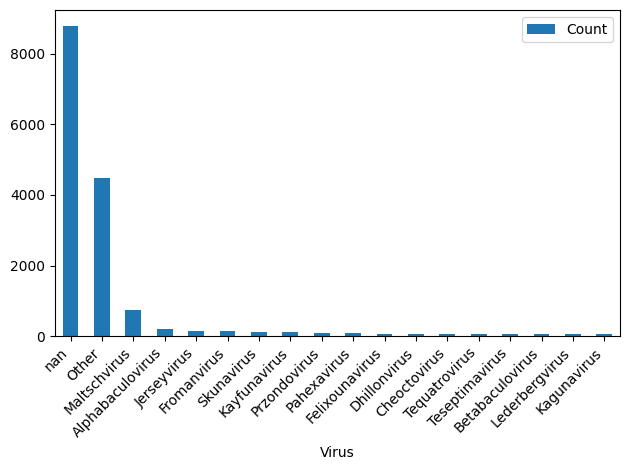

In [479]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(list(counts.items()), columns=['Virus', 'Count'])

# Define threshold (e.g. <=1 gets grouped)
threshold = 50

# Split into major + minor
major = df[df['Count'] > threshold]
minor = df[df['Count'] <= threshold]

# Sum minor counts into "Other"
other_count = minor['Count'].sum()

# Add "Other" row if needed
if other_count > 0:
    major = pd.concat([major, pd.DataFrame([['Other', other_count]], columns=['Virus', 'Count'])])

# Sort again
major = major.sort_values(by='Count', ascending=False)

# Plot
major.plot(kind='bar', x='Virus', y='Count')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [489]:
from collections import defaultdict

collapse_map = {
    'subphylum': 'phylum',
    'suborder': 'order',
    'subfamily': 'family',
    'subgenus': 'genus'
}

rank_values = defaultdict(set)

for entry in lineages:
    lineage = entry.get("lineage")

    if not lineage:
        continue

    for rank, value in lineage.items():
        # collapse rank first
        new_rank = collapse_map.get(rank, rank)
        rank_values[new_rank].add(value)

# Now count unique values per collapsed rank
collapsed_counts = {rank: len(values) for rank, values in rank_values.items()}

/var/folders/7y/g8zz31hx47955l5hvty2hyzh0000gn/T/ipykernel_8017/2614059045.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)


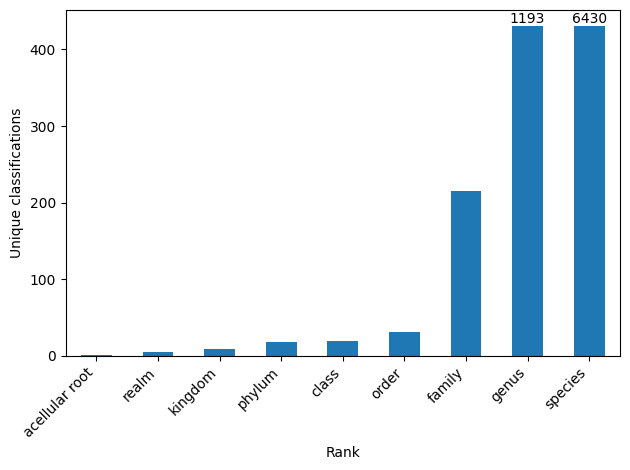

In [490]:
# ---- Plot ----
df = pd.DataFrame(list(collapsed_counts.items()), columns=['Rank', 'Count'])

rank_order = [
    'acellular root','realm','kingdom','phylum','class','order',
    'family','genus','species'
]

df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)
df = df.sort_values('Rank')
df = df[df['Rank'].notna()]

sorted_counts = df['Count'].sort_values(ascending=False).values
scale_value = sorted_counts[2] if len(sorted_counts) >= 3 else sorted_counts[-1]
cap_value = scale_value * 2

df_plot = df.copy()
real_values = {}

for i, row in df.iterrows():
    if row['Count'] > cap_value:
        real_values[row['Rank']] = row['Count']
        df_plot.loc[i, 'Count'] = cap_value

ax = df_plot.plot(kind='bar', x='Rank', y='Count', legend=False)

for i, row in df_plot.iterrows():
    rank = row['Rank']
    if rank in real_values:
        ax.text(i, cap_value, f"{real_values[rank]}",
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Unique classifications")
plt.tight_layout()
plt.show()

In [ ]:
# only problem is this plot has one less than what is in the code below

In [491]:
# Tommorow, more research about HMMs try to remake the prosite domains we used. I can scan against the uniprot database and it should reproduce the domain match fasta
# Do some wiriting up about what i have done to clean all the data

In [500]:
species=[]
for i in range(len(lineages)):
    species.append(lineages[i].get('lineage').get(''))

In [ ]:
unique_count = len(set(species))
unique_count

1194

In [512]:
from src.biotools.fasta_tools import read_fasta
seq=read_fasta('../uvsx/data/references/K35G_E198R.fasta')
seq[34]
#Error in the creating of this seq
#This position should have a G instead it has an R

'R'